In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.rcParams["figure.figsize"]=(12,6)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
fund = pd.read_csv(
    "../data/raw/01_fund_master.csv",
    encoding="latin1"
)

nav = pd.read_csv(
    "../data/processed/clean_nav.csv"
)

aum = pd.read_csv(
    "../data/raw/03_aum_by_fund_house.csv",
    encoding="latin1"
)

sip = pd.read_csv(
    "../data/raw/04_monthly_sip_inflows.csv",
    encoding="latin1"
)

category = pd.read_csv(
    "../data/raw/05_category_inflows.csv",
    encoding="latin1"
)

folio = pd.read_csv(
    "../data/raw/06_industry_folio_count.csv",
    encoding="latin1"
)

transactions = pd.read_csv(
    "../data/processed/clean_transactions.csv"
)

portfolio = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv",
    encoding="latin1"
)

print("All Files Loaded Successfully")

All Files Loaded Successfully


In [3]:
print("Fund:", fund.shape)
print("NAV:", nav.shape)
print("AUM:", aum.shape)
print("SIP:", sip.shape)
print("Transactions:", transactions.shape)

Fund: (40, 15)
NAV: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Transactions: (32778, 13)


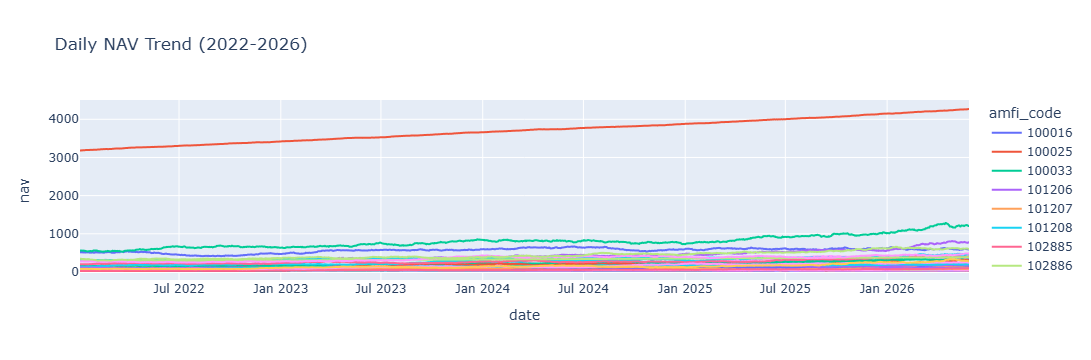

In [4]:
nav['date'] = pd.to_datetime(nav['date'])

fig = px.line(
    nav,
    x='date',
    y='nav',
    color='amfi_code',
    title='Daily NAV Trend (2022-2026)'
)

fig.show()

In [5]:
fig.write_html(
    "../charts/nav_trend.html"
)

In [7]:
print("AUM Columns")
print(aum.columns)

print("\nSIP Columns")
print(sip.columns)

print("\nCategory Columns")
print(category.columns)

print("\nTransactions Columns")
print(transactions.columns)

print("\nPortfolio Columns")
print(portfolio.columns)

AUM Columns
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')

SIP Columns
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

Category Columns
Index(['month', 'category', 'net_inflow_crore'], dtype='str')

Transactions Columns
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

Portfolio Columns
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


In [8]:
aum['date'] = pd.to_datetime(aum['date'])

aum['year'] = aum['date'].dt.year

print(aum.head())

        date           fund_house  aum_lakh_crore  aum_crore  num_schemes  \
0 2022-03-31      SBI Mutual Fund            6.05     605000          186   
1 2022-03-31  ICICI Prudential MF            4.65     465000          216   
2 2022-03-31     HDFC Mutual Fund            4.35     435000          195   
3 2022-03-31      Nippon India MF            2.70     270000          177   
4 2022-03-31    Kotak Mahindra MF            2.70     270000          168   

   year  
0  2022  
1  2022  
2  2022  
3  2022  
4  2022  


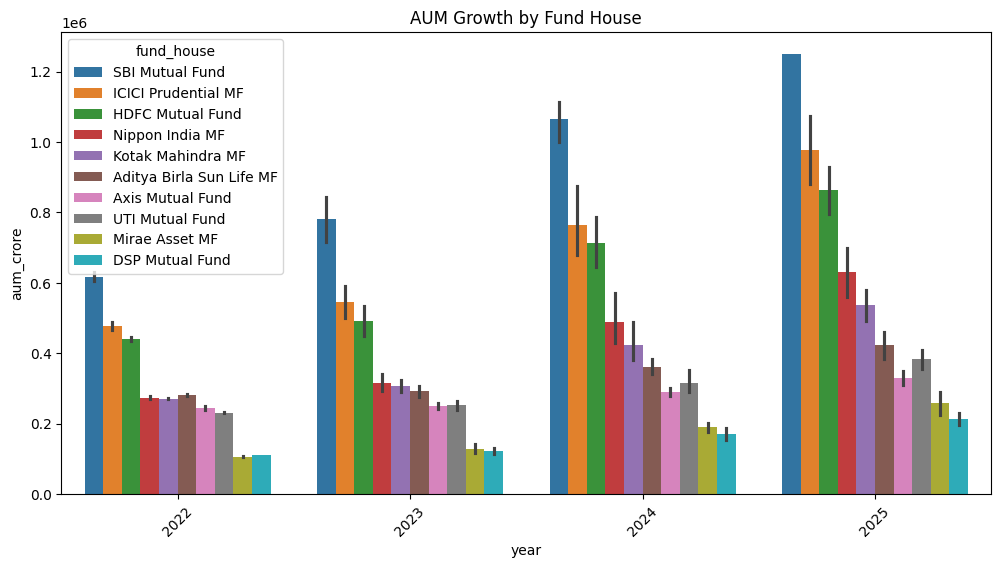

In [9]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x='year',
    y='aum_crore',
    hue='fund_house'
)

plt.title("AUM Growth by Fund House")
plt.xticks(rotation=45)

plt.savefig("../charts/aum_growth.png")

plt.show()

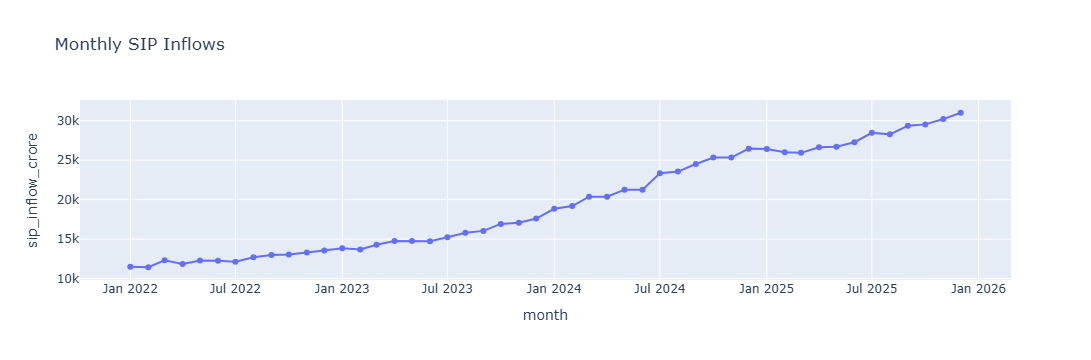

In [10]:
fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    markers=True,
    title='Monthly SIP Inflows'
)

fig.show()

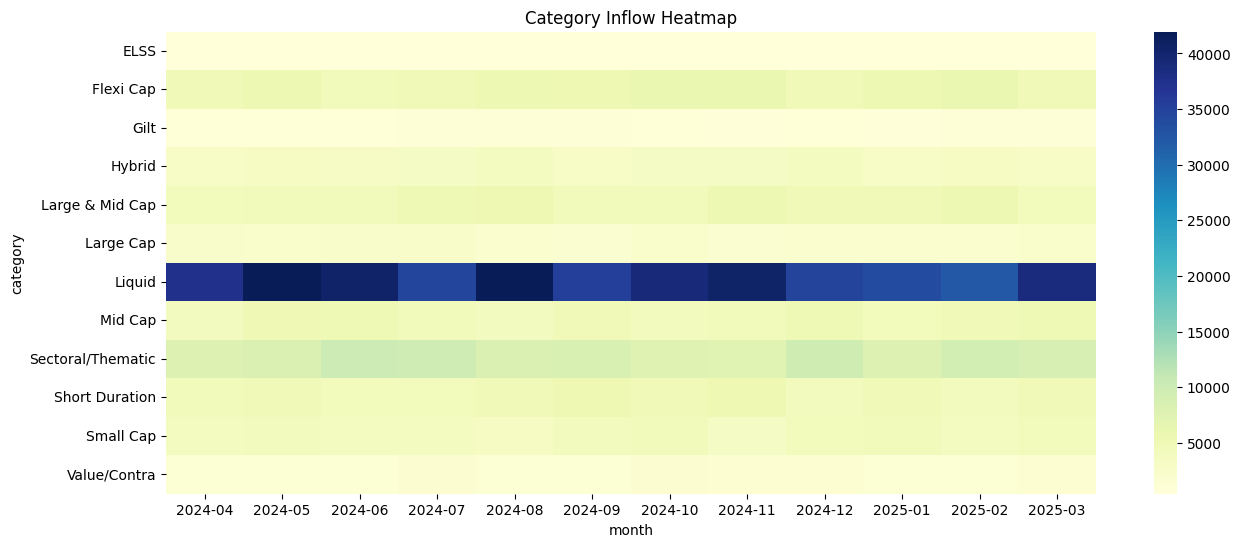

In [11]:
pivot = category.pivot_table(
    values='net_inflow_crore',
    index='category',
    columns='month'
)

plt.figure(figsize=(15,6))

sns.heatmap(
    pivot,
    cmap='YlGnBu'
)

plt.title("Category Inflow Heatmap")

plt.savefig("../charts/category_heatmap.png")

plt.show()

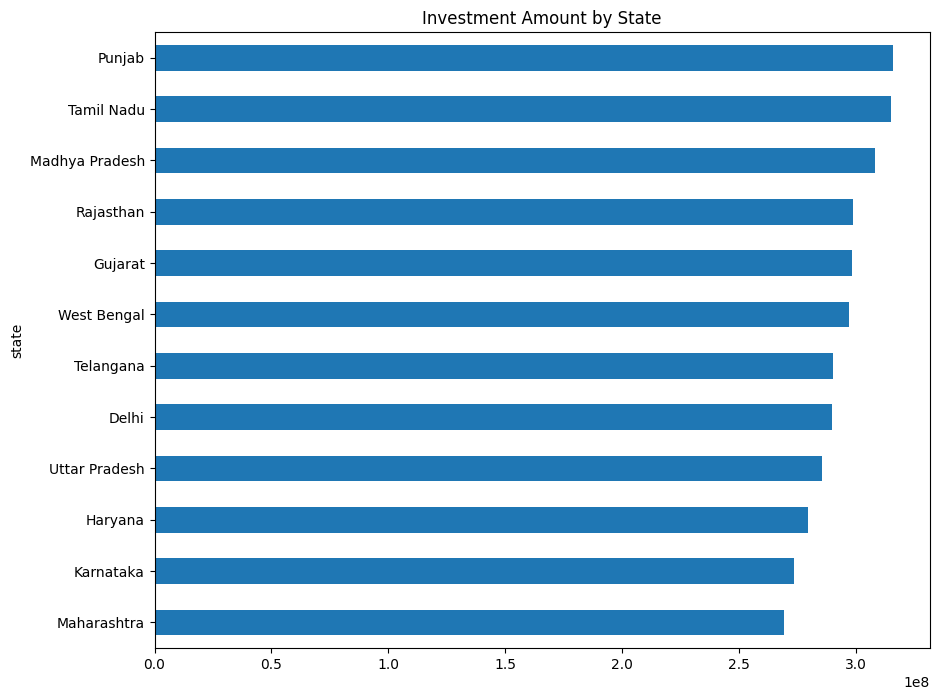

In [13]:
state_data = transactions.groupby(
    'state'
)['amount_inr'].sum().sort_values()

plt.figure(figsize=(10,8))

state_data.plot(
    kind='barh'
)

plt.title("Investment Amount by State")

plt.savefig("../charts/state_investment.png")

plt.show()

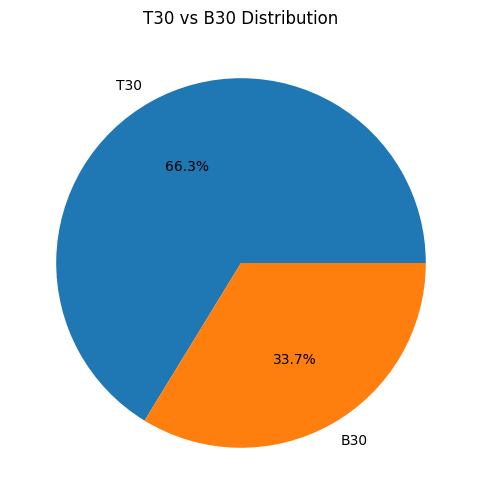

In [14]:
transactions['city_tier'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("T30 vs B30 Distribution")

plt.savefig("../charts/city_tier.png")

plt.show()

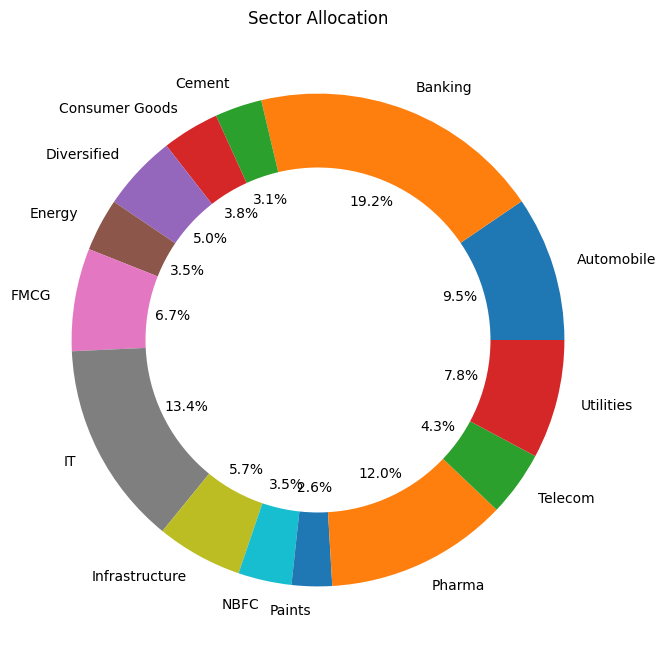

In [15]:
sector = portfolio.groupby(
    'sector'
)['weight_pct'].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    autopct='%1.1f%%'
)

centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc='white'
)

fig = plt.gcf()

fig.gca().add_artist(
    centre_circle
)

plt.title("Sector Allocation")

plt.savefig("../charts/sector_allocation.png")

plt.show()

In [16]:
print(fund.columns)

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')


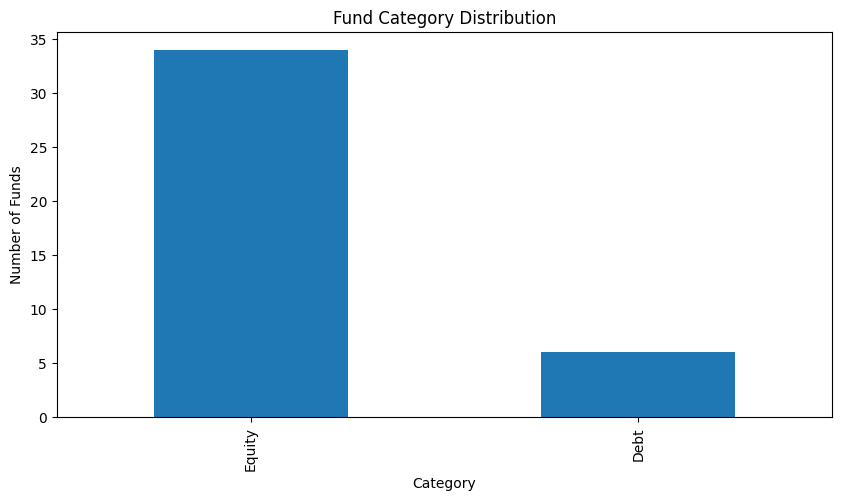

In [17]:
plt.figure(figsize=(10,5))

fund['category'].value_counts().plot(
    kind='bar'
)

plt.title("Fund Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Funds")

plt.savefig("../charts/fund_category_distribution.png")

plt.show()

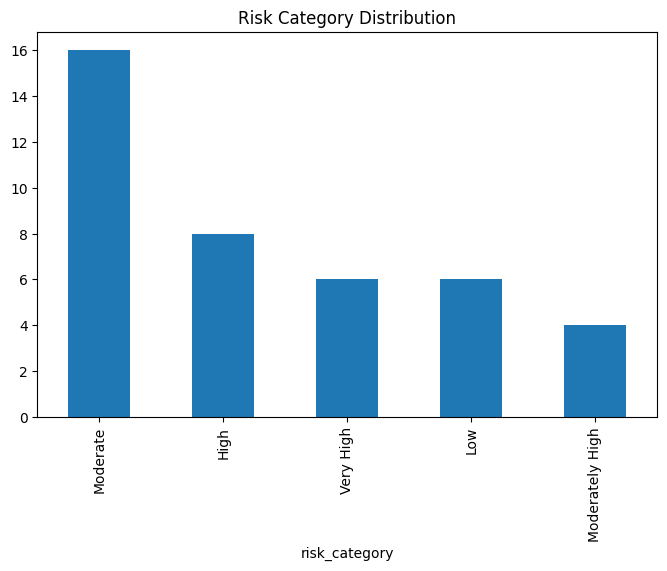

In [18]:
plt.figure(figsize=(8,5))

fund['risk_category'].value_counts().plot(
    kind='bar'
)

plt.title("Risk Category Distribution")

plt.savefig("../charts/risk_category_distribution.png")

plt.show()

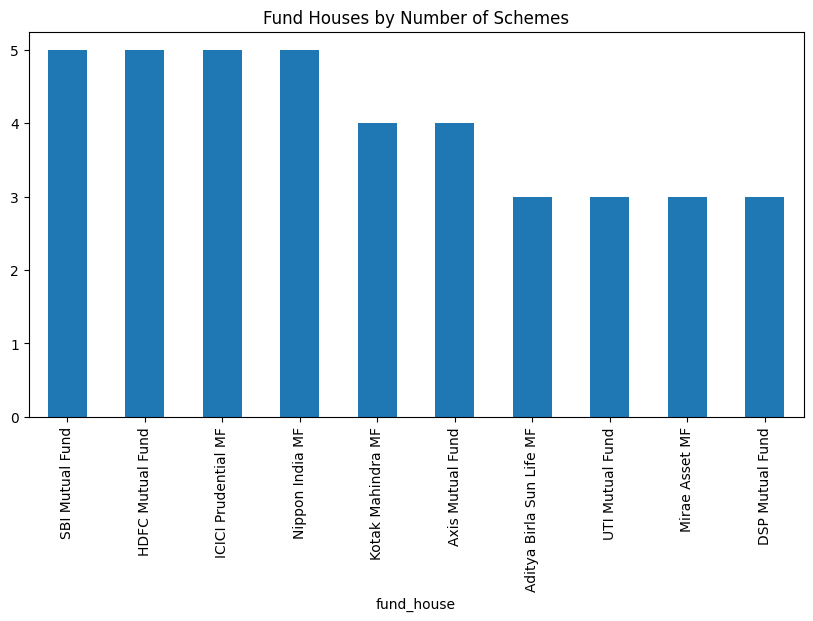

In [19]:
top_houses = fund['fund_house'].value_counts()

plt.figure(figsize=(10,5))

top_houses.plot(
    kind='bar'
)

plt.title("Fund Houses by Number of Schemes")

plt.savefig("../charts/fund_house_count.png")

plt.show()

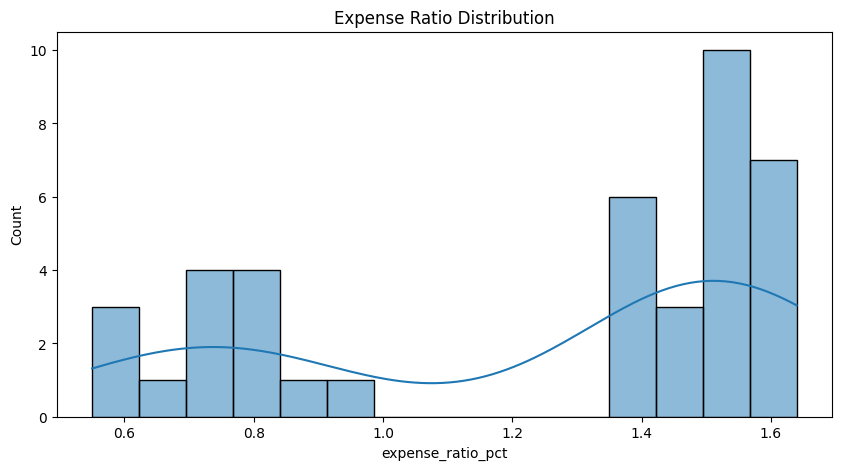

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(
    fund['expense_ratio_pct'],
    bins=15,
    kde=True
)

plt.title("Expense Ratio Distribution")

plt.savefig("../charts/expense_ratio_distribution.png")

plt.show()

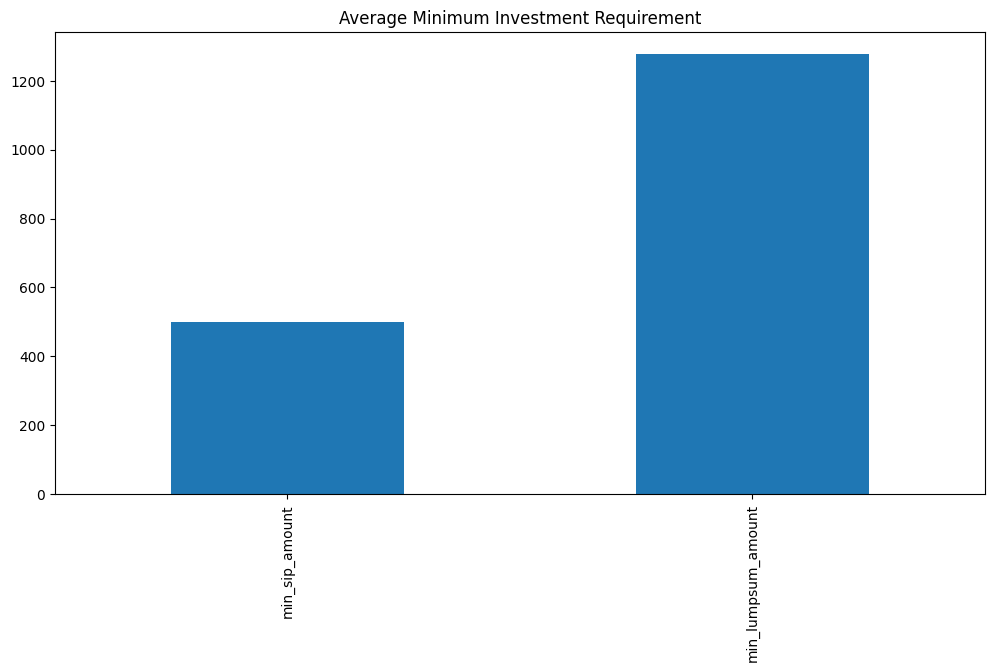

In [21]:
comparison = fund[
    ['min_sip_amount', 'min_lumpsum_amount']
].mean()

comparison.plot(
    kind='bar'
)

plt.title("Average Minimum Investment Requirement")

plt.savefig("../charts/minimum_investment.png")

plt.show()

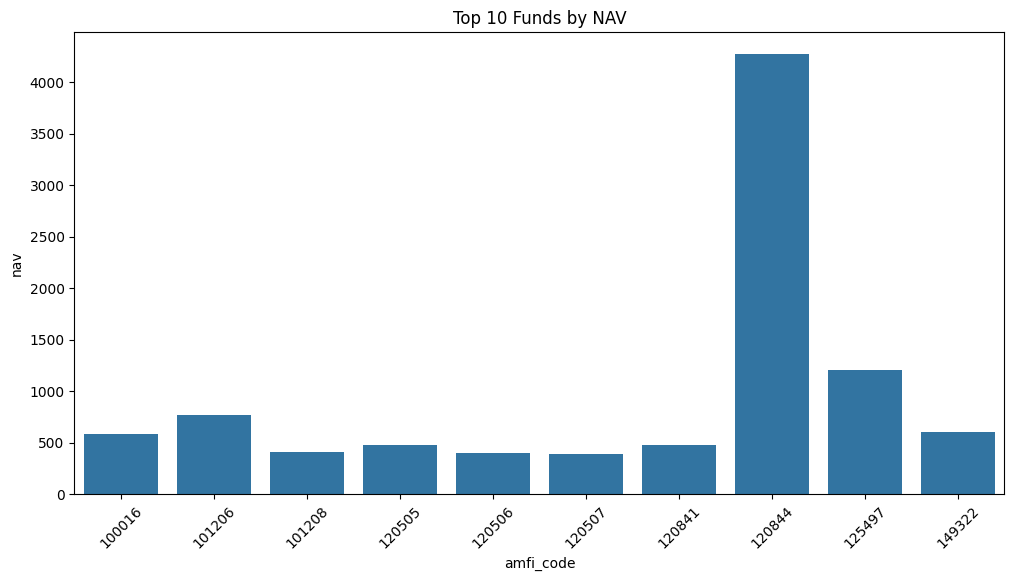

In [22]:
latest_nav = nav.sort_values(
    'date'
).groupby(
    'amfi_code'
).tail(1)

top10 = latest_nav.nlargest(
    10,
    'nav'
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x='amfi_code',
    y='nav'
)

plt.title("Top 10 Funds by NAV")

plt.xticks(rotation=45)

plt.savefig("../charts/top10_nav.png")

plt.show()

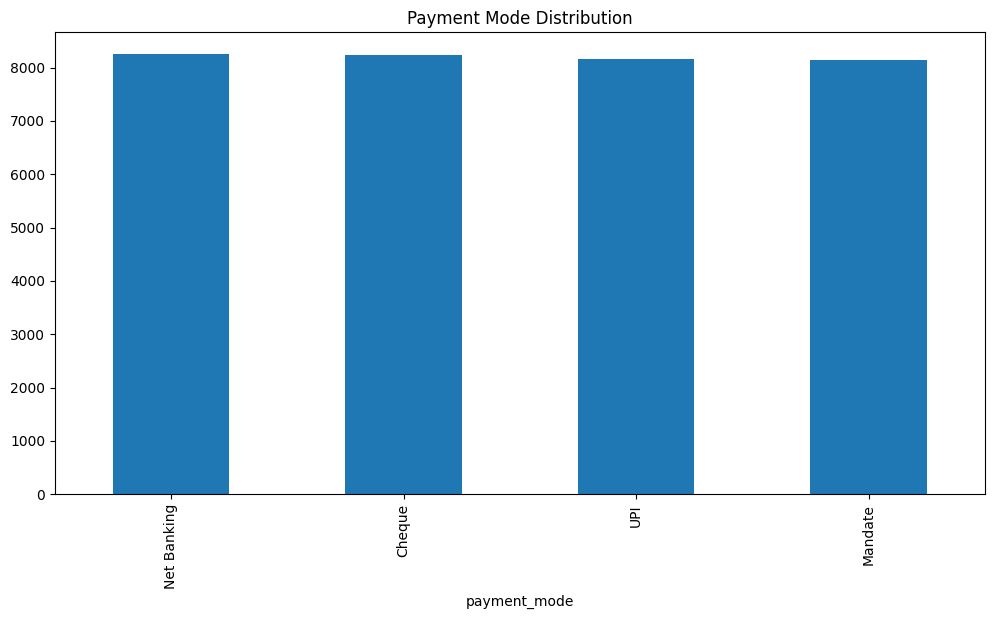

In [23]:
transactions['payment_mode'].value_counts().plot(
    kind='bar'
)

plt.title("Payment Mode Distribution")

plt.savefig("../charts/payment_mode.png")

plt.show()

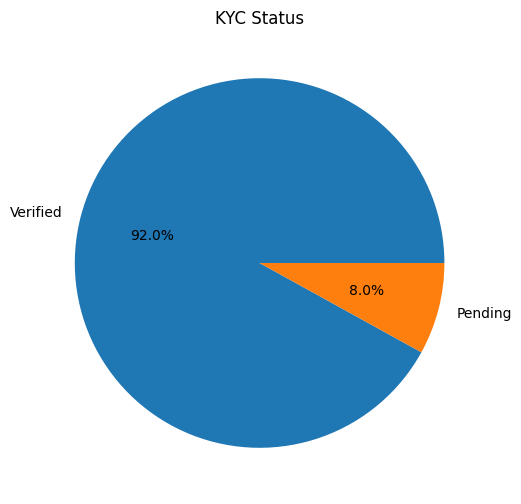

In [24]:
transactions['kyc_status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("KYC Status")

plt.savefig("../charts/kyc_status.png")

plt.show()